## Gradient Boosting Explained

Gradient Boosting is a powerful ensemble machine learning technique that builds a strong predictive model by combining multiple weaker models, typically decision trees. The core idea is to iteratively train new models that correct the errors of previous models. Here’s a detailed breakdown:

**1. Ensemble Learning:**
Gradient Boosting falls under the umbrella of ensemble learning, where the goal is to combine the predictions of several base learners (often called 'weak' learners) to produce a single, more accurate prediction. Unlike Bagging (e.g., Random Forests) which trains models independently and averages their predictions, Boosting trains models sequentially, with each new model trying to improve upon the shortcomings of the previous ones.

**2. Iterative Process (Sequential Learning):**

*   **Initial Model (F0):** The process begins with a simple initial model (F0), often just a constant value that minimizes the loss function (e.g., the average target value for regression, or log-odds for classification).
*   **Residuals (Errors):** For each subsequent iteration, the algorithm calculates the *residuals* (or pseudo-residuals for classification) from the current ensemble model's predictions. These residuals represent the errors that the current model is making. Specifically, for regression, it's the difference between the actual target value and the predicted value (Actual - Predicted).
*   **New Weak Learner (ht):** A new weak learner (often a shallow decision tree, called a 'regressor tree' regardless of whether it's for regression or classification) is trained to predict these residuals. The goal of this new tree is not to predict the target variable directly, but to predict the *errors* made by the previous ensemble.
*   **Adding to the Ensemble:** The predictions of this new weak learner are then multiplied by a small learning rate (shrinkage parameter) and added to the existing ensemble model. This step is crucial for preventing overfitting and allowing the model to generalize better.
    *   **Ft(x) = Ft-1(x) + α * ht(x)**
    *   Where Ft(x) is the updated ensemble model, Ft-1(x) is the previous ensemble model, α is the learning rate, and ht(x) is the prediction of the new weak learner.

**3. Gradient Descent Analogy:**
The 'Gradient' in Gradient Boosting refers to the fact that it uses a gradient descent optimization algorithm. Instead of directly minimizing the loss function with respect to the model parameters, it minimizes it by iteratively adding weak learners that are trained on the negative gradient of the loss function (the steepest descent direction). In simpler terms, each new weak learner is fitted to the residuals, which are essentially the negative gradients of the loss function for many common loss functions (like squared error for regression).

## Implementing Gradient Boosting with Scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

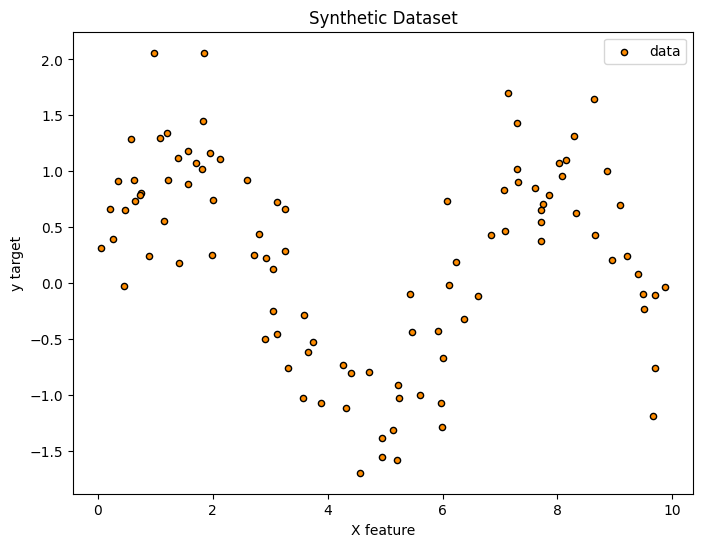

In [2]:
# 1. Create a synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 100) # y = sin(X) + noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.xlabel("X feature")
plt.ylabel("y target")
plt.title("Synthetic Dataset")
plt.legend()
plt.show()

In [3]:
# 2. Train a GradientBoostingRegressor model
# n_estimators: The number of boosting stages to perform.
# learning_rate: Shrinks the contribution of each tree by `learning_rate`.
# max_depth: The maximum depth of the individual regression estimators.

gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)

print("Gradient Boosting Regressor trained successfully!")

Gradient Boosting Regressor trained successfully!


In [4]:
# 3. Make predictions and evaluate the model
y_pred = gbr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error on test set: {mse:.4f}")

Mean Squared Error on test set: 0.1856


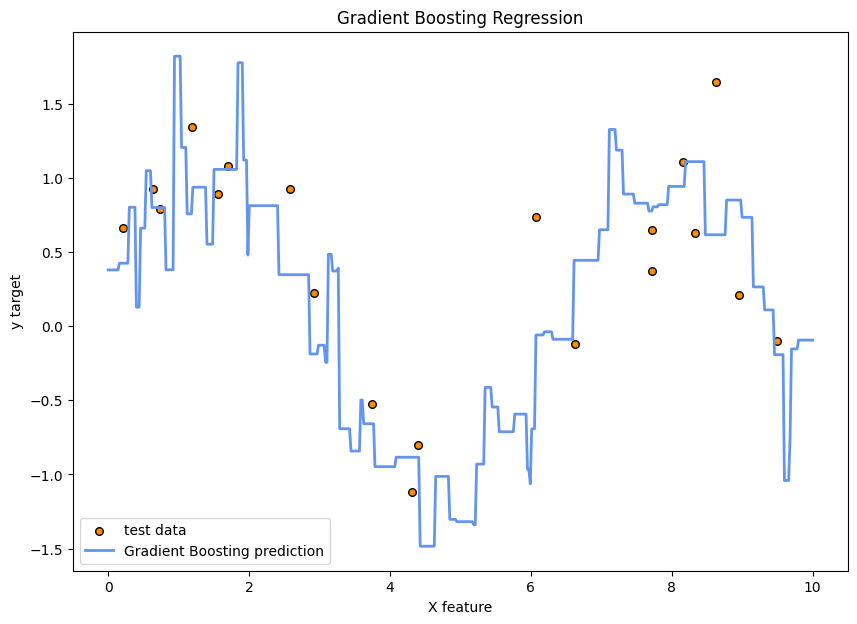

In [5]:
# 4. Visualize the results
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)
y_plot_pred = gbr.predict(X_plot)

plt.figure(figsize=(10, 7))
plt.scatter(X_test, y_test, s=30, edgecolor="black", c="darkorange", label="test data")
plt.plot(X_plot, y_plot_pred, color="cornflowerblue", linewidth=2, label="Gradient Boosting prediction")
plt.xlabel("X feature")
plt.ylabel("y target")
plt.title("Gradient Boosting Regression")
plt.legend()
plt.show()

# Gradient Boosting Regression

#1. Study hours vs Pass or Fail

In [6]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [7]:
data={
    "Hours_Studied":[
                1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        2, 4, 6, 8, 10
    ],

    "Attendance": [
        55, 60, 65, 70, 72,
        75, 80, 82, 88, 90,
        62, 68, 78, 85, 95
    ],

    "Previous_Marks": [
        40, 45, 50, 55, 60,
        65, 68, 72, 78, 85,
        48, 58, 66, 75, 90
    ],

    # TARGET
    "Final_Marks": [
        42, 47, 53, 58, 63,
        68, 72, 76, 82, 90,
        50, 61, 69, 79, 94
    ]

}
df=pd.DataFrame(data)

In [8]:
X=df.drop("Final_Marks",axis=1)
y=df["Final_Marks"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)


In [11]:
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [12]:
print("Actual:", y_test.values)
print("Predicted:", y_pred)

Actual: [90 61 42]
Predicted: [87.75387178 60.77831684 47.26365854]


In [13]:
print("\nMAE:",
      mean_absolute_error(y_test, y_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:",
      r2_score(y_test, y_pred))


MAE: 2.5771566387878573
RMSE: 3.3065761027697254
R2 Score: 0.9719335397288447


In [14]:
new_student = pd.DataFrame({
    "Hours_Studied": [7],
    "Attendance": [82],
    "Previous_Marks": [70]
})

prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 73.55619299371921


# Gradient Boosting Classification

In [15]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


# --------------------------------
# DATA
# --------------------------------

data = {
    "Hours_Studied": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        2, 4, 6, 8, 10
    ],

    "Attendance": [
        55, 60, 65, 70, 72,
        75, 80, 82, 88, 90,
        62, 68, 78, 85, 95
    ],

    "Previous_Marks": [
        40, 45, 50, 55, 60,
        65, 68, 72, 78, 85,
        48, 58, 66, 75, 90
    ],

    "Final_Marks": [
        42, 47, 53, 58, 63,
        68, 72, 76, 82, 90,
        50, 61, 69, 79, 94
    ]
}

df = pd.DataFrame(data)


# --------------------------------
# Create classification target
# --------------------------------

df["Result"] = (df["Final_Marks"] >= 50).astype(int)


# 0 = Fail
# 1 = Pass


# --------------------------------
# X and y
# --------------------------------

X = df[
    [
        "Hours_Studied",
        "Attendance",
        "Previous_Marks"
    ]
]

y = df["Result"]


# --------------------------------
# Train Test Split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------
# Gradient Boosting Classifier
# --------------------------------

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)


# --------------------------------
# Train
# --------------------------------

model.fit(X_train, y_train)


# --------------------------------
# Test
# --------------------------------

y_pred = model.predict(X_test)


print("Actual:", y_test.values)
print("Predicted:", y_pred)


# --------------------------------
# Evaluation
# --------------------------------

print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Actual: [1 1 1]
Predicted: [1 1 1]

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [16]:
new_student = pd.DataFrame({
    "Hours_Studied": [7],
    "Attendance": [82],
    "Previous_Marks": [70]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("PASS")
else:
    print("FAIL")

PASS


# Advanced Hyperparameter Tuning with GridSearchCV

In [17]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

data = load_diabetes()

X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = GradientBoostingRegressor(
    random_state=42
)


param_grid = {

    "n_estimators": [
        50,
        100,
        200
    ],

    "learning_rate": [
        0.01,
        0.05,
        0.1
    ],

    "max_depth": [
        2,
        3,
        4
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        3,
        5
    ]
}


grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)


grid.fit(X_train, y_train)


print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)


best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nTest R2:")
print(r2_score(y_test, y_pred))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


KeyboardInterrupt: 

# RandomizedSearchCV — Faster Hyperparameter Tuning

In [18]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

data = load_diabetes()

X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = GradientBoostingRegressor(
    random_state=42
)


param_grid = {

    "n_estimators": [
        50, 100, 150, 200, 300
    ],

    "learning_rate": [
        0.01, 0.03, 0.05,
        0.1, 0.2
    ],

    "max_depth": [
        2, 3, 4, 5
    ],

    "min_samples_split": [
        2, 5, 10, 15
    ],

    "min_samples_leaf": [
        1, 2, 4, 8
    ]
}


random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)


print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

KeyboardInterrupt: 

# Compare Four Regression Models

In [19]:
from sklearn.datasets import load_diabetes

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np


data = load_diabetes()

X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=3,
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            max_depth=3,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )


    r2 = r2_score(
        y_test,
        pred
    )


    print(
        f"{name:20} "
        f"RMSE={rmse:.2f} "
        f"R2={r2:.3f}"
    )

Linear Regression    RMSE=53.85 R2=0.453
Decision Tree        RMSE=59.60 R2=0.329
Random Forest        RMSE=53.04 R2=0.469
Gradient Boosting    RMSE=52.77 R2=0.474
